In [2]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# 1. 데이터 불러오기 (한글 인코딩)
df = pd.read_csv("./archive/한국전력거래소_시간별 전국 전력수요량_20241231.csv", encoding="euc-kr")

# 2. melt로 시간 분해
df_long = df.melt(id_vars=["날짜"], var_name="hour", value_name="DEMAND")
df_long["hour"] = df_long["hour"].str.replace("시", "").astype(int) - 1
df_long["datetime"] = pd.to_datetime(df_long["날짜"]) + pd.to_timedelta(df_long["hour"], unit="h")

# 3. 파생 변수 생성
df_long["hourOfDay"] = df_long["datetime"].dt.hour
df_long["dayOfWeek"] = df_long["datetime"].dt.dayofweek
df_long["weekend"] = (df_long["dayOfWeek"] >= 5).astype(int)

# 4. 과거 시계열 특성 생성
df_long.sort_values("datetime", inplace=True)
df_long.reset_index(drop=True, inplace=True)

for i in range(1, 5):
    df_long[f"week_X-{i}"] = df_long["DEMAND"].shift(24 * 7 * i)
df_long["MA_X-4"] = df_long[[f"week_X-{i}" for i in range(1, 5)]].mean(axis=1)

# 5. 결측치 제거
df_model = df_long.dropna().copy()

# 6. 피처 및 타겟 설정
features = ["week_X-1", "week_X-2", "week_X-3", "week_X-4", "MA_X-4", "hourOfDay", "dayOfWeek", "weekend"]
target = "DEMAND"

X = df_model[features]
y = df_model[target]

# 7. 학습/검증 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.2)

# 8. XGBoost 모델 학습
model = XGBRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 9. 예측 및 평가
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))  
mape = mean_absolute_percentage_error(y_test, y_pred)

print(f"✅ RMSE: {rmse:.2f}")
print(f"✅ MAPE: {mape:.4f}")


✅ RMSE: 3747.80
✅ MAPE: 0.0400


In [24]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from scipy.stats import zscore

# 1. 데이터 불러오기
df = pd.read_csv("./archive/한국전력거래소_시간별 전국 전력수요량_20241231.csv", encoding="euc-kr")

# 2. melt
df_long = df.melt(id_vars=["날짜"], var_name="hour", value_name="DEMAND")
df_long["hour"] = df_long["hour"].str.replace("시", "").astype(int) - 1
df_long["datetime"] = pd.to_datetime(df_long["날짜"]) + pd.to_timedelta(df_long["hour"], unit="h")

# 3. 파생 변수
df_long["hourOfDay"] = df_long["datetime"].dt.hour
df_long["dayOfWeek"] = df_long["datetime"].dt.dayofweek
df_long["weekend"] = (df_long["dayOfWeek"] >= 5).astype(int)

# 4. 시계열 특성 생성
df_long.sort_values("datetime", inplace=True)
df_long.reset_index(drop=True, inplace=True)

for i in range(1, 5):
    df_long[f"week_X-{i}"] = df_long["DEMAND"].shift(24 * 7 * i)
df_long["MA_X-4"] = df_long[[f"week_X-{i}" for i in range(1, 5)]].mean(axis=1)

# 5. 결측치 제거
df_model = df_long.dropna().copy()

#  6. z score 2 기준 이상치 탐지 (z-score 기준)
z_scores = zscore(df_model[["DEMAND"]])
df_model["zscore"] = z_scores
df_model_no_outlier = df_model[df_model["zscore"].abs() <= 2].copy()

# 7. 학습
features = ["week_X-1", "week_X-2", "week_X-3", "week_X-4", "MA_X-4", "hourOfDay", "dayOfWeek", "weekend"]
target = "DEMAND"

X = df_model_no_outlier[features]
y = df_model_no_outlier[target]

# z-score 제거 이후에 반드시 다시 split 해야 함
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.2)

# 모델 학습
model_clean = XGBRegressor(n_estimators=100, random_state=42)
model_clean.fit(X_train, y_train)

# 예측 및 평가
y_pred = model_clean.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred)

print(f"✅ [z-score 2 기준 이상치 제거 후] RMSE: {rmse:.2f}")
print(f"✅ [z-score 2 기준 이상치 제거 후] MAPE: {mape:.4f}")


✅ [z-score 2 기준 이상치 제거 후] RMSE: 3727.19
✅ [z-score 2 기준 이상치 제거 후] MAPE: 0.0399


In [25]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from scipy.stats import zscore

# 1. 데이터 불러오기
df = pd.read_csv("./archive/한국전력거래소_시간별 전국 전력수요량_20241231.csv", encoding="euc-kr")

# 2. melt
df_long = df.melt(id_vars=["날짜"], var_name="hour", value_name="DEMAND")
df_long["hour"] = df_long["hour"].str.replace("시", "").astype(int) - 1
df_long["datetime"] = pd.to_datetime(df_long["날짜"]) + pd.to_timedelta(df_long["hour"], unit="h")

# 3. 파생 변수
df_long["hourOfDay"] = df_long["datetime"].dt.hour
df_long["dayOfWeek"] = df_long["datetime"].dt.dayofweek
df_long["weekend"] = (df_long["dayOfWeek"] >= 5).astype(int)

# 4. 시계열 특성 생성
df_long.sort_values("datetime", inplace=True)
df_long.reset_index(drop=True, inplace=True)

for i in range(1, 5):
    df_long[f"week_X-{i}"] = df_long["DEMAND"].shift(24 * 7 * i)
df_long["MA_X-4"] = df_long[[f"week_X-{i}" for i in range(1, 5)]].mean(axis=1)

# 5. 결측치 제거
df_model = df_long.dropna().copy()

# 6. z-score 3 기준 이상치 탐지 (z-score 기준)
z_scores = zscore(df_model[["DEMAND"]])
df_model["zscore"] = z_scores
df_model_no_outlier = df_model[df_model["zscore"].abs() <= 3].copy()

# 7. 학습
features = ["week_X-1", "week_X-2", "week_X-3", "week_X-4", "MA_X-4", "hourOfDay", "dayOfWeek", "weekend"]
target = "DEMAND"

X = df_model_no_outlier[features]
y = df_model_no_outlier[target]

# z-score 제거 이후에 반드시 다시 split 해야 함
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.2)

# 모델 학습
model_clean = XGBRegressor(n_estimators=100, random_state=42)
model_clean.fit(X_train, y_train)

# 예측 및 평가
y_pred = model_clean.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred)

print(f"✅ [z-score 3 기준 이상치 제거 후] RMSE: {rmse:.2f}")
print(f"✅ [z-score 3 기준 이상치 제거 후] MAPE: {mape:.4f}")


✅ [z-score 3 기준 이상치 제거 후] RMSE: 3667.69
✅ [z-score 3 기준 이상치 제거 후] MAPE: 0.0394


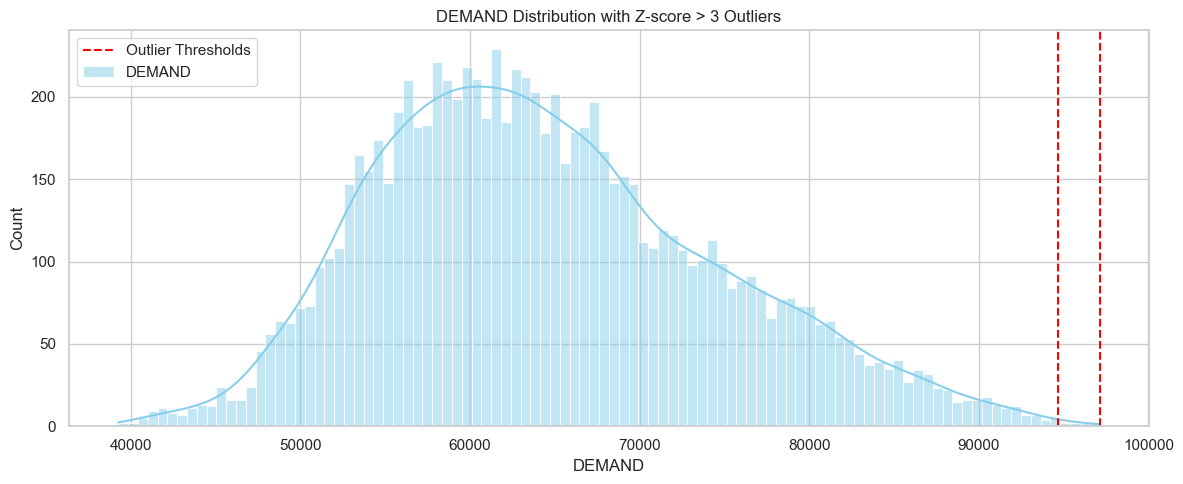

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

# 1. 데이터 로드
df = pd.read_csv("./archive/한국전력거래소_시간별 전국 전력수요량_20241231.csv", encoding="euc-kr")

# 2. melt 형태로 변환
df_long = df.melt(id_vars=["날짜"], var_name="hour", value_name="DEMAND")
df_long["hour"] = df_long["hour"].str.replace("시", "").astype(int) - 1
df_long["datetime"] = pd.to_datetime(df_long["날짜"]) + pd.to_timedelta(df_long["hour"], unit="h")

# 3. z-score 이상치 계산
df_long["z_demand"] = zscore(df_long["DEMAND"])
df_long["outlier"] = abs(df_long["z_demand"]) > 3

# 4. 시각화
sns.set(style="whitegrid")
plt.figure(figsize=(12, 5))
sns.histplot(df_long["DEMAND"], bins=100, kde=True, color="skyblue", label="DEMAND")
plt.axvline(df_long.loc[df_long["outlier"], "DEMAND"].min(), color='red', linestyle='--', label='Outlier Thresholds')
plt.axvline(df_long.loc[df_long["outlier"], "DEMAND"].max(), color='red', linestyle='--')
plt.title("DEMAND Distribution with Z-score > 3 Outliers")
plt.xlabel("DEMAND")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()


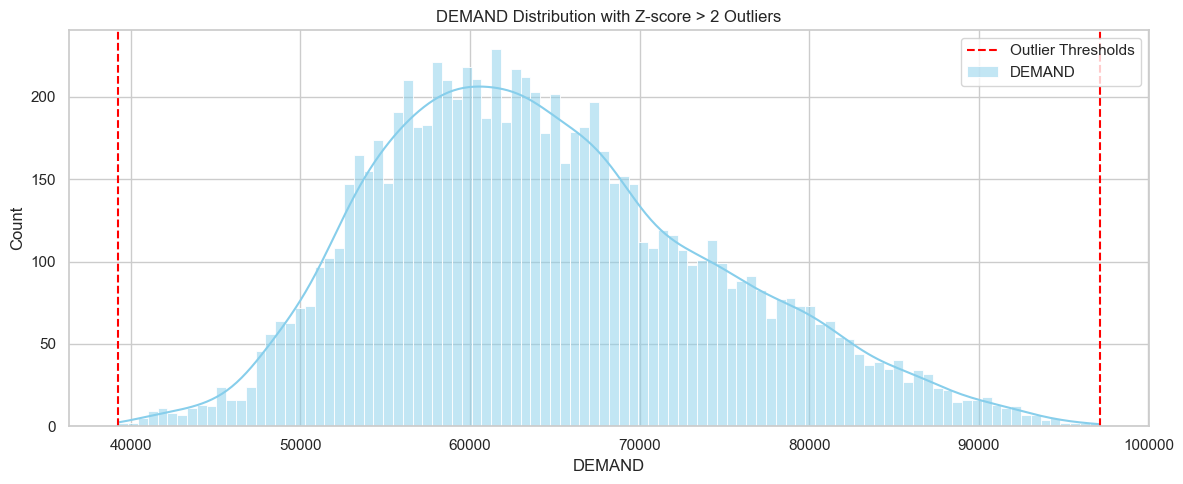

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

# 1. 데이터 로드
df = pd.read_csv("./archive/한국전력거래소_시간별 전국 전력수요량_20241231.csv", encoding="euc-kr")

# 2. melt 형태로 변환
df_long = df.melt(id_vars=["날짜"], var_name="hour", value_name="DEMAND")
df_long["hour"] = df_long["hour"].str.replace("시", "").astype(int) - 1
df_long["datetime"] = pd.to_datetime(df_long["날짜"]) + pd.to_timedelta(df_long["hour"], unit="h")

# 3. z-score 이상치 계산
df_long["z_demand"] = zscore(df_long["DEMAND"])
df_long["outlier"] = abs(df_long["z_demand"]) > 2

# 4. 시각화
sns.set(style="whitegrid")
plt.figure(figsize=(12, 5))
sns.histplot(df_long["DEMAND"], bins=100, kde=True, color="skyblue", label="DEMAND")
plt.axvline(df_long.loc[df_long["outlier"], "DEMAND"].min(), color='red', linestyle='--', label='Outlier Thresholds')
plt.axvline(df_long.loc[df_long["outlier"], "DEMAND"].max(), color='red', linestyle='--')
plt.title("DEMAND Distribution with Z-score > 2 Outliers")
plt.xlabel("DEMAND")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()


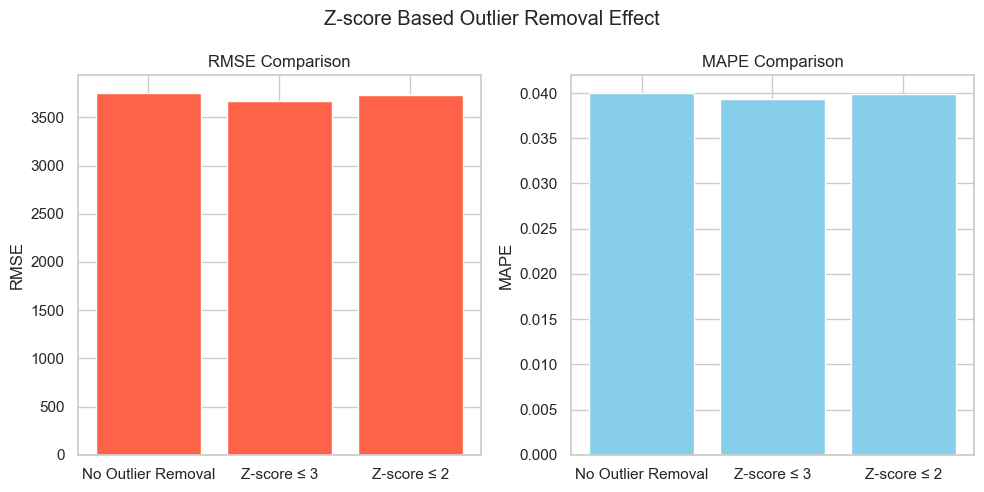

                label         rmse      mape
0  No Outlier Removal  3747.801222  0.039960
1         Z-score ≤ 3  3667.689600  0.039359
2         Z-score ≤ 2  3727.187948  0.039867


In [23]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from scipy.stats import zscore
import matplotlib.pyplot as plt

# 1. 데이터 불러오기 및 전처리
df = pd.read_csv("./archive/한국전력거래소_시간별 전국 전력수요량_20241231.csv", encoding="euc-kr")
df_long = df.melt(id_vars=["날짜"], var_name="hour", value_name="DEMAND")
df_long["hour"] = df_long["hour"].str.replace("시", "").astype(int) - 1
df_long["datetime"] = pd.to_datetime(df_long["날짜"]) + pd.to_timedelta(df_long["hour"], unit="h")
df_long["hourOfDay"] = df_long["datetime"].dt.hour
df_long["dayOfWeek"] = df_long["datetime"].dt.dayofweek
df_long["weekend"] = (df_long["dayOfWeek"] >= 5).astype(int)
df_long.sort_values("datetime", inplace=True)
df_long.reset_index(drop=True, inplace=True)
for i in range(1, 5):
    df_long[f"week_X-{i}"] = df_long["DEMAND"].shift(24 * 7 * i)
df_long["MA_X-4"] = df_long[[f"week_X-{i}" for i in range(1, 5)]].mean(axis=1)
df_model = df_long.dropna().copy()

# 2. 평가용 함수 정의
def train_and_evaluate(data, label):
    X = data[features]
    y = data[target]
    X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.2)
    model = XGBRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = mean_absolute_percentage_error(y_test, y_pred)
    return {"label": label, "rmse": rmse, "mape": mape}

# 3. 피처 지정
features = ["week_X-1", "week_X-2", "week_X-3", "week_X-4", "MA_X-4", "hourOfDay", "dayOfWeek", "weekend"]
target = "DEMAND"

# 4. z-score 기준별 모델 평가
results = []

# 4-1. 원본 그대로
results.append(train_and_evaluate(df_model.copy(), "No Outlier Removal"))

# 4-2. z > 3 제거
df_model["zscore"] = zscore(df_model["DEMAND"])
df_z3 = df_model[df_model["zscore"].abs() <= 3].copy()
results.append(train_and_evaluate(df_z3, "Z-score ≤ 3"))

# 4-3. z > 2 제거
df_model["zscore"] = zscore(df_model["DEMAND"])
df_z2 = df_model[df_model["zscore"].abs() <= 2].copy()
results.append(train_and_evaluate(df_z2, "Z-score ≤ 2"))

# 5. 결과 시각화
results_df = pd.DataFrame(results)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.bar(results_df["label"], results_df["rmse"], color="tomato")
plt.title("RMSE Comparison")
plt.ylabel("RMSE")

plt.subplot(1, 2, 2)
plt.bar(results_df["label"], results_df["mape"], color="skyblue")
plt.title("MAPE Comparison")
plt.ylabel("MAPE")

plt.suptitle("Z-score Based Outlier Removal Effect")
plt.tight_layout()
plt.show()

# 6. 수치 결과 출력
print(results_df)


테이블 4~5개 이상치 제거 전 후
시각화 
데이터셋 구축